$\text{Libraries}$

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_models import LinearFactorMixedModel,MixtureClassificationModel,TeacherStudentModel, exponential_covariance,create_downsampling_matrix,MNISTDataModel
from losses_regularizers import LogisticLoss, QuadraticRegularizer, PseudoHuberRegularizer,SquaredLoss,HingeLoss
from erm_theory import ERMTrainer, TheoryFixedPointSolver

$\text{Problem setting}$

In [ ]:
#Gaussian
c = 4
n = c * 10
p = c * 15

mu = np.zeros(p); mu[0] = 1.0

C = exponential_covariance(p, rho=0.5)
covs = [C, C]

theta_star = np.zeros(p); theta_star[0] = 1

model = TeacherStudentModel(
    p=p,
    mu_x=mu,
    C_x=C,
    feature_dist="uniform_iid",
    theta_teacher=theta_star,
    noise_std = 1
)
loss = SquaredLoss()

In [3]:
# LFMM
n = 50
p = 50
q = 5
P = 0.5
s = np.ones(q)           
std = 1 

rng = np.random.default_rng()
rng2 = np.random.default_rng()

model = LinearFactorMixedModel(p,q,P,s,std)
loss = LogisticLoss()

$\text{Simulation}$

In [4]:
# Calculating the empirical and theoretial solutions 
lam = 1.0
n = 1
t_values = np.arange(0, n)

mu0 = None
alpha0 = None
nu0 = None

# Theory settings
mc_samples = 6000
fp_max_iter = 1000
fp_tol = 2e-5
fp_damping = 0.1


num_trials = 50
n_test = 1

theory_preds = []
theory_converged = []
nu_th = []
kappa_th = []
alpha_th = []
mu_th =[]
empirical_means = []
empirical_stds = []

for t in t_values:
    print(f"\n===== t = {t} =====")

    # Define a vector a
    a = np.zeros(p)
    a[q] = 1

    # Quadratic regularizer: (1/2) x^T H x + a^T x
    H = lam * np.eye(p)
    reg = QuadraticRegularizer(a=a, H=H)

    # ================= Empirical =================
    trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
    emp = trainer.run_trials(
        n_train=n,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )

    empirical_means.append(emp["gen_loss_mean"])
    empirical_stds.append(emp["gen_loss_std"])

    print(
        f"Empirical gen loss: mean={emp['gen_loss_mean']:.6f}  "
        f"std={emp['gen_loss_std']:.6f}"
    )

    # ================= Theory =================
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n,
        mc_samples=mc_samples,
        rng=np.random.default_rng(123),
    )

    th = solver.solve(
        max_iter=fp_max_iter,
        tol=fp_tol,
        damping=fp_damping,
        verbose=False,
        mu0=mu0,
        alpha0=alpha0,
        nu0=nu0,
    )

    theory_preds.append(th["predicted_loss"])
    theory_converged.append(bool(th["converged"]))

    # Warm start
    mu0, alpha0, nu0 = th["mu_star"], th["alpha"], th["nu"]
    nu_th.append(th["nu"])
    kappa_th.append(th["kappa"])
    alpha_th.append(th["alpha"])
    mu_th.append(th["mu_star"])

    print(
        f"Theory predicted loss: {th['predicted_loss']:.6f}  "
        f"(converged={th['converged']}, iters={th['num_iter']})"
    )

mu_th = th["mu_star"]
alpha = th["alpha"][0]


===== t = 0 =====
Empirical gen loss: mean=0.759145  std=0.485813
Theory predicted loss: 0.692295  (converged=True, iters=729)


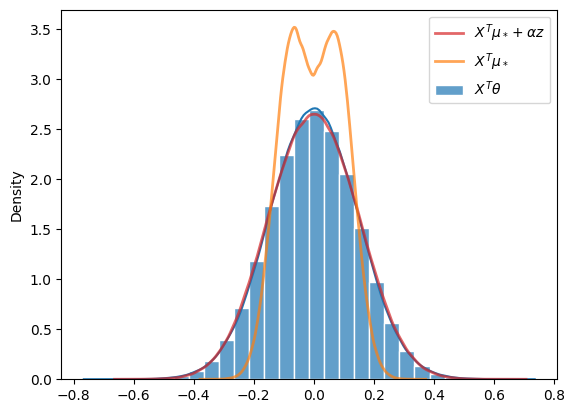

In [ ]:
# Comparing theory with empirical results 

def sample_emp(ns):
    return np.random.multivariate_normal(np.array(emp["mean_theta"]),np.array(emp["cov_theta"]),size=ns)

ns = 1000000
X, y = model.sample(ns)
thetas = sample_emp(ns)
z = np.random.normal(size=ns)

# Plot X^T theta
sns.histplot(
    np.einsum("ij,ij->i", X, thetas),
    bins=30,
    stat="density",
    kde=True,
    color="tab:blue",             
    edgecolor="white",       
    linewidth=1.0,
    alpha=0.7,
    line_kws={"color": "black", "linewidth": 1.5},  
    label=r"$X^T \theta$"      # label for legend
)

# Plot X^T mu_* + alpha z
sns.kdeplot(
    X @ mu_th + alpha * z,
    color="tab:red",             
    linewidth=2.0,
    alpha=0.7,

    label=r"$X^T \mu_* + \alpha z$"  # label for legend
)

# Plot X^T mu_*
sns.kdeplot(
    X @ mu_th ,
    color="tab:orange",             
    linewidth=2.0,
    alpha=0.7,
    label=r"$X^T \mu_* $"  # label for legend
)
plt.legend()
plt.show()


In [5]:
# Theorem 7.1 related simulations 
from scipy.special import expit

alpha = th['alpha'][0]
mu_st = th['mu_star']
kappa = th['kappa'][0]

def score_samples(n: int,mu : Array): 
     z = np.random.normal(size=n)
     X,y = model.sample(n)
     return X @ mu + alpha* z , y 

def logistic_moreau(z: Array, kappa: float, y: Array, max_iter: int = 60, tol: float = 1e-10) -> Array:
        """
        Compute prox_{kappa * logistic_y}(z) elementwise using Newton.

        Solve for w:
          0 = (w - z) - kappa * y / (1 + exp(y w))
        """
        z = np.asarray(z, dtype=float)
        y = np.asarray(y, dtype=float)
        k = float(kappa)

        # Initial guess: w0 = z
        w = z.copy()

        # Vectorized Newton iterations
        for _ in range(max_iter):
            t = y * w
            sig_t = expit(t)          # sigmoid(t)
            h = expit(-t)             # 1/(1+exp(t))
            g = (w - z) - k * y * h
            gprime = 1.0 + k * sig_t * (1.0 - sig_t)

            step = g / gprime
            w_new = w - step

            if np.max(np.abs(w_new - w)) < tol:
                w = w_new
                break
            w = w_new

        return (w-z)**2/(2*k) + loss.value(w,y)


reg = QuadraticRegularizer(a,H)

def Jmu(t : int, v, reg, n : int=100): 
    mu_t = mu_st + t * v #/np.linalg.norm(v)
    z,y = score_samples(n,mu_t)
    E = np.mean(logistic_moreau(z,kappa,y))
    return E + reg.value(mu_t)

In [6]:
span =-0.5
T = np.linspace(-span,span,100)

v ,vF, vT = np.random.normal(size = p),np.random.normal(size = p),np.random.normal(size = p)
vF[q:] = np.zeros(p-q)
vT[q+1:] = np.zeros(p-q-1)


def plot_Jmu(v : Array) :
    X=[]
    for t in T : 
        X.append(Jmu(t,v,reg,n=50000))
    X = np.array(X)
    return X

base = plot_Jmu(np.zeros(p))
x = plot_Jmu(v)
xf = plot_Jmu(vF)
xt = plot_Jmu(vT)

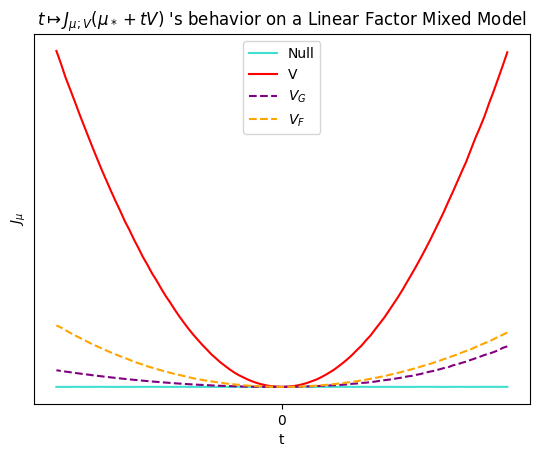

In [9]:
plt.plot(T,base, color='turquoise',label="Null")
plt.plot(T, x, color='red', label='V')
plt.plot(T, xt, color = 'purple',linestyle = '--', label=r'$V_G$')  
plt.plot(T, xf, color = 'orange',linestyle = '--',label=r'$V_F$')  
# remove all y-axis numbers


ax = plt.gca()  # get current axes

# remove all y-axis numbers
ax.set_yticks([])

# keep only 0 on the x-axis
ax.set_xticks([0])
ax.set_xticklabels([r"$0$"])
plt.xlabel('t')
plt.ylabel(r'$J_\mu$')
plt.legend()
plt.title(r"$t\mapsto J_{\mu;V}(\mu_* + t V)$ 's behavior on a Linear Factor Mixed Model")
plt.show()

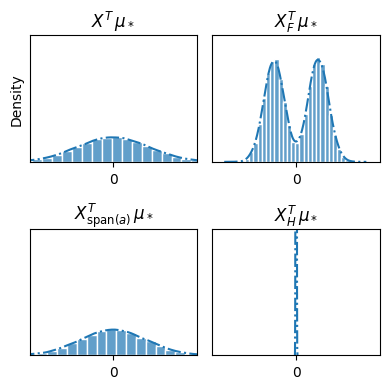

In [17]:
# Plots configured for the dimensions of lambda = 1
X, y = model.sample(50000)

layer1 = X[:, :q] @ mu_th[:q]
layer2 = X[:, q] * mu_th[q]
layer3 = X[:, q+1:] @ mu_th[q+1:]
layer4 = X @ mu_th

titles = [
    r"$X^T\,\mu_*$",
    r"$X_F^T\,\mu_*$",
    r"$X_{\text{span}(a)}^T\,\mu_*$",
    r"$X_{H}^T\,\mu_*$"
]

samples_list = [layer4, layer1, layer2, layer3]
colors = ["tab:blue"] * 4
xlimits = [(-2.4, 2.4), (-1, 1), (-2.5, 2.5), (-1, 1)]

fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharey=True)

for ax, samples, title, xlimit, color in zip(
        axes.flat, samples_list, titles, xlimits, colors):

    # Histogram
    sns.histplot(
        samples,
        bins=30,
        stat="density",
        kde=False,
        color=color,
        edgecolor="white",
        linewidth=1.0,
        alpha=0.7,
        ax=ax
    )

    # KDE (black dash–dot)
    sns.kdeplot(
        samples,
        color="tab:blue",
        linewidth=1.5,
        linestyle="dashdot",
        ax=ax
    )

    xmin, xmax = xlimit
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 2)
    ax.set_title(title)
    ax.set_xticks([0])
    ax.set_yticks([])

# Y label only on left column (paper style)
axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")

plt.tight_layout()
plt.show()


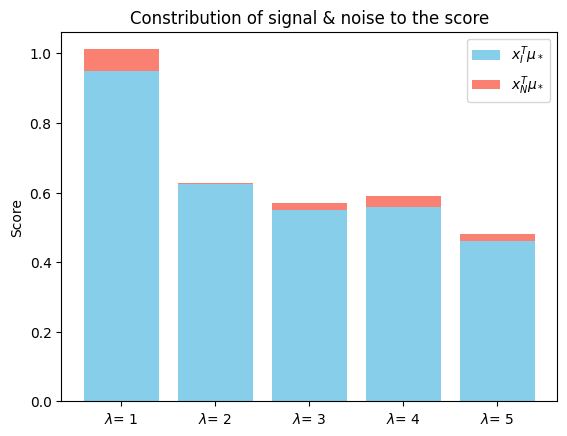

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ns = 5

X,y = model.sample_class(1,ns)
XI,XN = np.zeros([ns,p]), np.zeros([ns,p])

XI[:,:q] = X[:,:q]
XN[:,q:] = X[:,q:]

I = [XI[i]@mu_th[i] for i in range(5)]
N = [XN[i]@mu_th[i] for i in range(5)]

labels = [rf"$\lambda$= {x+1}" for x in range(ns)] 

# Plot stacked bars
fig, ax = plt.subplots()
ax.bar(labels, I, color='skyblue', label=r'$x_I^T\mu_*$')
ax.bar(labels, N, bottom=I, color='salmon', label=r'$x_N^T\mu_*$')  


ax.set_ylabel('Score')
ax.set_title('Constribution of signal & noise to the score')
ax.legend()
plt.show()


$\textbf{TeacherStudentModel}$

In [ ]:
from scipy.special import expit

alpha = th['alpha'][0]
mu_st = th['mu_star']
kappa = th['kappa'][0]


def square_moreau(z: Array, kappa: float, y: Array, max_iter: int = 60, tol: float = 1e-10) -> Array:
        """
        Compute prox_{kappa * logistic_y}(z) elementwise using Newton.

        Solve for w:
          0 = (w - z) - kappa * y / (1 + exp(y w))
        """
        z = np.asarray(z, dtype=float)
        y = np.asarray(y, dtype=float)
        k = float(kappa)

        w = z.copy()

        # Vectorized Newton iterations
        for _ in range(max_iter):
            t = y * w
            sig_t = expit(t)          # sigmoid(t)
            h = expit(-t)             # 1/(1+exp(t))
            g = (w - z) - k * y * h
            gprime = 1.0 + k * sig_t * (1.0 - sig_t)

            step = g / gprime
            w_new = w - step

            if np.max(np.abs(w_new - w)) < tol:
                w = w_new
                break
            w = w_new       

        return (w-z)**2/(2*k) + loss.value(w,y)

a = np.zeros((p,1))
H = np.eye(p)

reg = QuadraticRegularizer(a,H)

def Jmu(t : int, v : Array, reg, n : int=100): 
    mu_t = mu_st + t * v #/np.linalg.norm(v)
    z,y = score_samples(n,mu_t)
    E = np.mean(logistic_moreau(z,kappa,y))
    return E + reg.value(mu_t)

In [ ]:
from scipy.special import expit

alpha = th['alpha'][0]
mu_st = th['mu_star']
kappa = th['kappa'][0]

mumu = theta_star.reshape(p,1)@theta_star.reshape(1,p)

def square_moreau(mu_st: Array, kappa: float) -> Array:
    return 1/(2*kappa)*((mu_st-theta_star)@(C+mumu)@(mu_st-theta_star)+alpha**2)

a = np.zeros((p,1))
H = np.eye(p)

reg = QuadraticRegularizer(a,H)

def Jmu(t : int, v : Array, reg, n : int=100): 
    mu_t = mu_st + t * v #/np.linalg.norm(v)
    E = np.mean(square_moreau(mu_t,kappa))
    return E + reg.value(mu_t)

In [234]:
v = np.random.normal(size=p)

vI = v@theta_star * theta_star


T = np.linspace(-10,10,100)

def plot_Jmu(v : Array) :
    X=[]
    for t in T : 
        X.append(Jmu(t,v,reg,n=50000))
    X = np.array(X)
    return X

base = plot_Jmu(np.zeros(p))
X = plot_Jmu(v)
XI = plot_Jmu(vI)


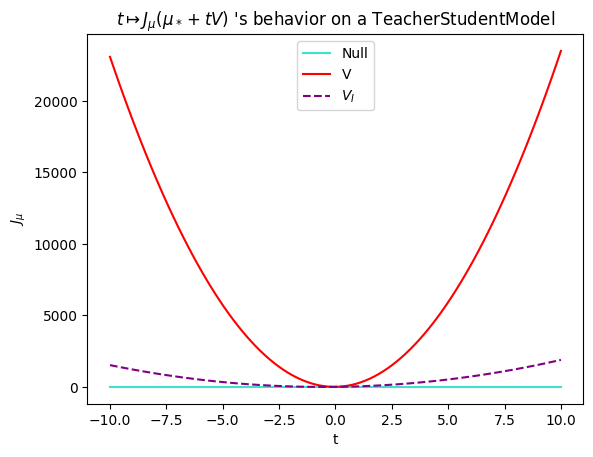

In [ ]:
plt.plot(T,base, color='turquoise',label="Null")
plt.plot(T, X, color='red', label='V')
plt.plot(T, XI, color = 'purple',linestyle = '--', label=r'$V_I$')   # default color is fine


plt.xlabel('t')
plt.ylabel(r'$J_\mu$')
plt.legend()
plt.title(r"$t\mapsto J_\mu(\mu_* + t V)$ 's behavior on a TeacherStudentModel")
plt.show()